In [1]:
using Revise
using Distributions
using Flux: DataLoader 
using LinearAlgebra

using KernelFunctions
import ComponentArrays:ComponentArray


using CairoMakie
using ColorSchemes


include("src/rgp.jl")
using .RegressionGP


# sin(x)

In [2]:
## Dummy test
limit_test = [-8, 8]
limit_basis = [-8, 8]
step_test = 0.03
std_test = 0.01 
## Test
X_test = collect(limit_test[1]:step_test:limit_test[2])
Y_test = sin.(X_test) + rand(Normal(0, std_test), size(X_test)[1])
dataLoader = DataLoader((X_test, Y_test), batchsize=9, shuffle=true)

60-element DataLoader(::Tuple{Vector{Float64}, Vector{Float64}}, shuffle=true, batchsize=9)
  with first element:
  (9-element Vector{Float64}, 9-element Vector{Float64},)

In [3]:
limit_basis = [-10, 10]
step_basis = 0.7
X_basis = collect(limit_test[1]:step_basis:limit_test[2])
σ = 0.01

kernel = 2 * with_lengthscale(SEKernel(),1)
rgp = RGPModel(kernel, σ, X_basis);

In [4]:
rgp_learn(rgp, dataLoader)

In [5]:
limit_predict = [-10, 10]
step_predict = 0.32
X_predict =  collect(limit_predict[1]:step_predict:limit_predict[2])
Y_predict = sin.(X_predict)
mu, C = predict(rgp, X_predict)
σ = sqrt.(diag(C));

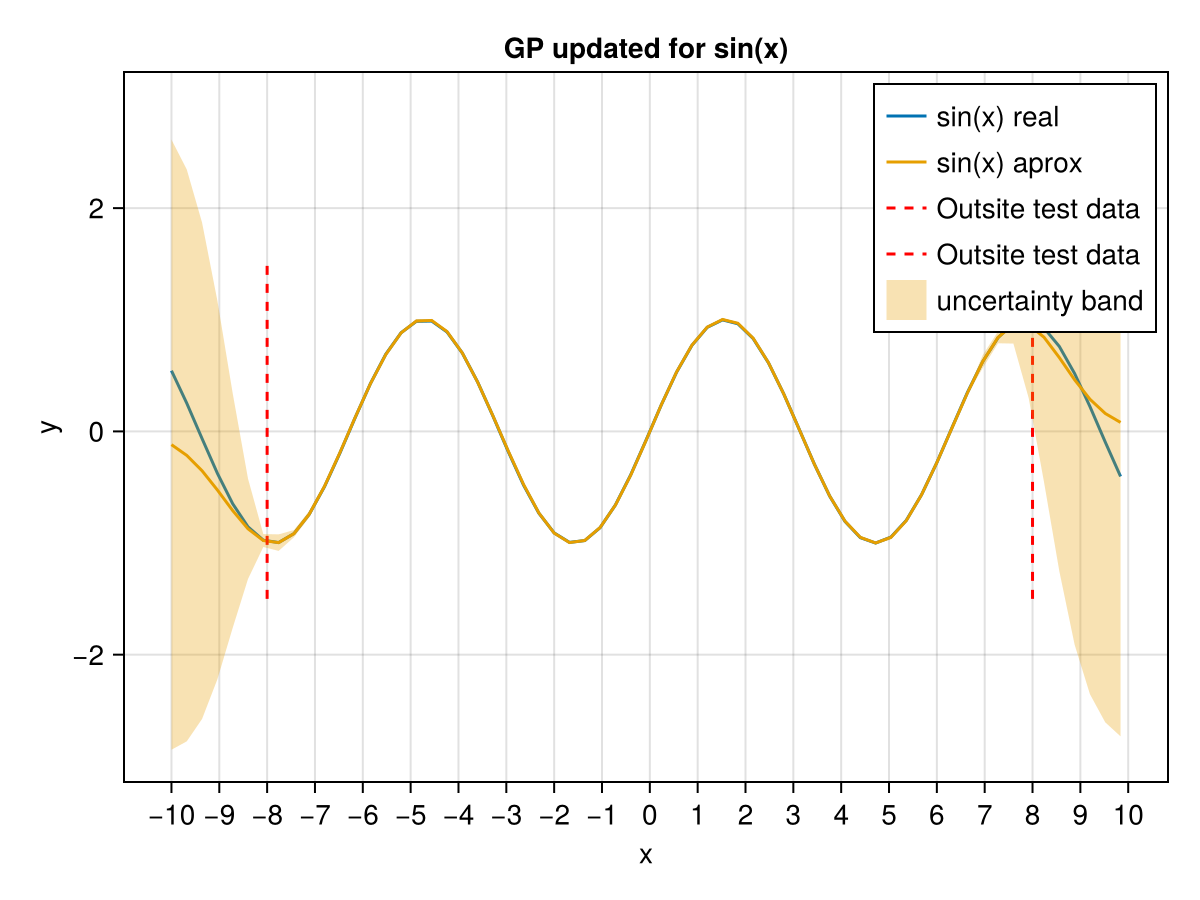

CairoMakie.Screen{IMAGE}


In [6]:
fig = Figure()
ax = Axis(fig[1, 1], title = "GP updated for sin(x)" , xlabel = "x", ylabel = "y", xticks = limit_predict[1]:1:limit_predict[2])
lines!(ax, X_predict, Y_predict, label = "sin(x) real")
lines!(ax, X_predict, mu, label = "sin(x) aprox")
lines!(ax, [limit_test[1], limit_test[1]],[-1.5, 1.5], color = :red,  linestyle = :dash, label = "Outsite test data")
lines!(ax, [limit_test[2], limit_test[2]],[-1.5, 1.5], color = :red,  linestyle = :dash, label = "Outsite test data")

band!(ax, X_predict, mu - 2σ, mu + 2σ; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
axislegend(ax)
display(fig)

# $ x/2 + 25 \cdot x/(1 + x^2) \cdot cos(x) $

In [7]:
## Dummy test
limit_test = [-8, 8]
limit_basis = [-8, 8]
step_test = 0.03
std_test = 0.01 

## Test
X_test = collect(limit_test[1]:step_test:limit_test[2])
Y_test = X_test/2 + 25*X_test./(1 .+ X_test.^2) .* cos.(X_test) + rand(Normal(0, std_test), size(X_test)[1])
dataLoader = DataLoader((X_test, Y_test), batchsize=9, shuffle=true);

In [8]:

## Basis
limit_basis = [-10, 10]
step_basis = 0.7
X_basis = collect(limit_basis[1]:step_basis:limit_basis[2])

σ = 0.01

kernel = 2 * with_lengthscale(SEKernel(),1);

rgp = RGPModel(kernel, σ, X_basis)
rgp_learn(rgp, dataLoader);

In [ ]:
limit_predict = [-10, 10]
step_predict = 0.02
X_predict =  collect(limit_predict[1]:step_predict:limit_predict[2])
Y_predict = X_predict/2 + 25*X_predict./(1 .+ X_predict.^2) .* cos.(X_predict)
mu, C = predict(rgp, X_predict)
σ = sqrt.(diag(C));

fig = Figure()
ax = Axis(fig[1, 1], title = "GP updated for x/2 + 25  x/(1 + x^2) cos(x)", xlabel = "x", ylabel = "y", xticks = limit_predict[1]:1:limit_predict[2])
lines!(ax, X_predict, Y_predict, label = "f(x) real")
lines!(ax, X_predict, mu, label = "f(x) aprox")
lines!(ax, [limit_test[1], limit_test[1]],[-10, 10], color = :red,  linestyle = :dash, label = "Outsite test data")
lines!(ax, [limit_test[2], limit_test[2]],[-10, 10], color = :red,  linestyle = :dash, label = "Outsite test data")

band!(ax, X_predict, mu - 2σ, mu + 2σ; label="uncertainty band", color=(Makie.wong_colors()[2], 0.3))
display(fig)
